# Гипотеза H4. Роль объёма новостей

## Блок 1. Импорт библиотек и параметры

In [1]:
import os
import re
import json
import math
import hashlib
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

warnings.simplefilter("default")
np.random.seed(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

OUTPUT_DIR = "outputs_01"
MASTER_PATH = os.path.join(OUTPUT_DIR, "returns_sentiment_enhanced.parquet")
ANALYSIS_DIR = os.path.join(OUTPUT_DIR, "analysis_03-H4")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

TEST_START = pd.Timestamp("2023-01-01")
ALPHA = 0.05

HORIZON_MAP = {"y1_ex": 1, "y2_ex": 2, "y3_ex": 3, "y5_ex": 5}


NEWS_FILTER_COL = "has_news_today"
USE_NEWS_ONLY_PRIMARY = True
MAIN_MODEL = "finbert_tone"
APPLY_TRAIN_WINSOR = True
WINSOR_P = 0.01


FE_MAX_ITERS = 200
FE_TOL = 1e-10


STRICT_CHECKS = True
RUN_TWFE_CHECK = True
TWFE_CHECK_MAX_ROWS = 1200
TWFE_CHECK_MAX_TICKERS = 20
TWFE_CHECK_MAX_DATES = 25


TEST_SORT_Q = 5
RUN_PERMUTATION_TEST = False
N_PERMUTATIONS = 200


USE_CACHE = True

PRIMARY_MODEL_ORDER = [
    "finbert",
    "finbert_tone",
    "finroberta",
    "distilroberta_finnews",
    "deberta_finnews",
    "twroberta",
    "vader",
    "textblob",
]

print("Путь к master-файлу:", MASTER_PATH)
print("Директория анализа:", ANALYSIS_DIR)
print("Граница тестовой выборки:", TEST_START.date())
print("Основная модель:", MAIN_MODEL)

from IPython.display import display as _ipython_display

MODEL_NAME_MAP = {}
SPEC_NAME_MAP = {}
FAMILY_NAME_MAP = {}
HORIZON_NAME_MAP = {}
NEWS_BIN_NAME_MAP = {}
SECTOR_NAME_MAP = {}

TEXT_VALUE_MAP = {
    "единое пересечение наблюдений для всех моделей": "единое пересечение наблюдений для всех моделей",
    "стековая FE-модель идентифицирует только различия наклонов относительно h1": "стековая FE-модель идентифицирует только различия наклонов относительно h1",
}


def pretty_model_name(x):
    return x


def pretty_spec_name(x):
    return x


def pretty_family_name(x):
    return x


def pretty_horizon_name(x):
    return x


def pretty_sector_name(x):
    return x


def pretty_metric_name(x):
    return x


def pretty_label_text(x):
    if pd.isna(x):
        return x
    return TEXT_VALUE_MAP.get(str(x), x)


def pretty_sample_note(x):
    if pd.isna(x):
        return x
    return TEXT_VALUE_MAP.get(str(x), x)


def pretty_section_name(x):
    return x


def pretty_column_name(col):
    return col


def localize_df_for_display(df):
    out = df.copy()
    for col in ["sample_note", "stacked_spec_note", "label", "section", "extra"]:
        if col in out.columns:
            out[col] = out[col].map(lambda v: TEXT_VALUE_MAP.get(str(v), v) if pd.notna(v) else v)
    return out


def display(*objs, **kwargs):
    localized = [localize_df_for_display(obj) if isinstance(obj, pd.DataFrame) else obj for obj in objs]
    return _ipython_display(*localized, **kwargs)

Путь к master-файлу: outputs_01/returns_sentiment_enhanced.parquet
Директория анализа: outputs_01/analysis_03-H4
Граница тестовой выборки: 2023-01-01
Основная модель: finbert_tone


## Блок 2. Загрузка мастер-панели

Подгружается мастер-датасет, проверяется наличие нужных столбцов и определяется набор доступных моделей тональности

In [2]:
def file_signature(path: str) -> Dict:
    st = os.stat(path)
    return {
        "path": os.path.abspath(path),
        "size_bytes": int(st.st_size),
        "mtime_utc": pd.to_datetime(st.st_mtime, unit="s", utc=True).isoformat(),
    }

if not os.path.exists(MASTER_PATH):
    raise FileNotFoundError(
        f"Не найден master-датасет: {MASTER_PATH}\n"
        "Сначала запустите ноутбук 02, чтобы создать returns_sentiment_enhanced.parquet."
    )

MASTER_SIG = file_signature(MASTER_PATH)
MASTER_SIG.update({
    "TEST_START": str(TEST_START.date()),
    "NEWS_FILTER_COL": NEWS_FILTER_COL,
    "USE_NEWS_ONLY_PRIMARY": USE_NEWS_ONLY_PRIMARY,
    "MAIN_MODEL": MAIN_MODEL,
    "APPLY_TRAIN_WINSOR": APPLY_TRAIN_WINSOR,
    "WINSOR_P": WINSOR_P,
    "FE_MAX_ITERS": FE_MAX_ITERS,
    "FE_TOL": FE_TOL,
    "TEST_SORT_Q": TEST_SORT_Q,
    "STRICT_CHECKS": STRICT_CHECKS,
})

try:
    import pyarrow.parquet as pq
    pf = pq.ParquetFile(MASTER_PATH)
    ALL_COLS = pf.schema.names
except Exception:
    tmp = pd.read_parquet(MASTER_PATH)
    ALL_COLS = list(tmp.columns)
    del tmp

required_base_cols = ["ticker", "date"] + list(HORIZON_MAP.keys())
missing_base_cols = [c for c in required_base_cols if c not in ALL_COLS]
if missing_base_cols:
    raise KeyError(f"В master-parquet не хватает обязательных столбцов: {missing_base_cols}")

if USE_NEWS_ONLY_PRIMARY and NEWS_FILTER_COL not in ALL_COLS:
    raise KeyError(f"Столбец '{NEWS_FILTER_COL}' обязателен для выборки только с новостями.")

def available_primary_models(cols: List[str]) -> List[str]:
    out = []
    for m in PRIMARY_MODEL_ORDER:
        if f"{m}_score_mean" in cols:
            out.append(m)
    return out

PRIMARY_MODELS = available_primary_models(ALL_COLS)
if not PRIMARY_MODELS:
    raise ValueError("В master-parquet не найдено основных моделей тональности.")

if MAIN_MODEL not in PRIMARY_MODELS:
    raise ValueError(
        f"Указанная основная модель MAIN_MODEL='{MAIN_MODEL}' недоступна. "
        f"Доступные модели: {PRIMARY_MODELS}"
    )

BASE_COLS = [
    "ticker", "date",
    "ret_log", "mkt_ret_log", "excess_ret_log",
    "y1_ex", "y2_ex", "y3_ex", "y5_ex",
    "news_n", "has_news_today", "sector",
]
BASE_COLS = [c for c in BASE_COLS if c in ALL_COLS]

MODEL_COLS = []
for m in PRIMARY_MODELS:
    for suf in ["_score_mean", "_neg_share", "_pos_share", "_neu_share", "_news_count"]:
        c = f"{m}{suf}"
        if c in ALL_COLS:
            MODEL_COLS.append(c)

COLS_TO_LOAD = sorted(set(BASE_COLS + MODEL_COLS))
df = pd.read_parquet(MASTER_PATH, columns=COLS_TO_LOAD)

df["ticker"] = df["ticker"].astype(str).str.strip()
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
if "news_n" in df.columns:
    df["news_n"] = pd.to_numeric(df["news_n"], errors="coerce")
if "has_news_today" in df.columns:
    df["has_news_today"] = pd.to_numeric(df["has_news_today"], errors="coerce")

df = df.dropna(subset=["ticker", "date"]).copy()
df = df.sort_values(["ticker", "date"], kind="mergesort").reset_index(drop=True)

for y_col, h in HORIZON_MAP.items():
    df[f"date_plus_{h}"] = df.groupby("ticker", sort=False)["date"].shift(-h)

if "excess_ret_log" in df.columns:
    df["lag1_excess_ret"] = df.groupby("ticker", sort=False)["excess_ret_log"].shift(1)

MASTER_SIG["PRIMARY_MODELS"] = PRIMARY_MODELS
MASTER_SIG["N_SOURCE_COLUMNS"] = len(ALL_COLS)

with open(os.path.join(ANALYSIS_DIR, "master_signature.json"), "w", encoding="utf-8") as f:
    json.dump(MASTER_SIG, f, ensure_ascii=False, indent=2)

print("Число строк:", f"{len(df):,}")
print("Число тикеров:", int(df["ticker"].nunique()))
print("Период:", df["date"].min().date(), "—", df["date"].max().date())
print("Доступные модели:", PRIMARY_MODELS)

Число строк: 2,580,236
Число тикеров: 2054
Период: 2019-01-02 — 2023-12-28
Доступные модели: ['finbert', 'finbert_tone', 'finroberta', 'distilroberta_finnews', 'deberta_finnews', 'twroberta', 'vader', 'textblob']


## Блок 3. Вспомогательные функции

Функции, которые нужны для подготовки данных, оценивания моделей и статистических тестов

### Блок 3.1. Кэширование и FDR

Функции для чтения и сохранения промежуточных результатов, а также для поправки Бенджамини–Хохберга

In [3]:
def load_cache(path: str, sig_path: str, current_sig: Dict) -> Optional[pd.DataFrame]:
    if not (os.path.exists(path) and os.path.exists(sig_path)):
        return None
    try:
        with open(sig_path, "r", encoding="utf-8") as f:
            sig = json.load(f)
        if sig != current_sig:
            return None
        return pd.read_parquet(path)
    except Exception:
        return None


def save_cache(df_out: pd.DataFrame, path: str, sig_path: str, current_sig: Dict) -> None:
    df_out.to_parquet(path, index=False)
    with open(sig_path, "w", encoding="utf-8") as f:
        json.dump(current_sig, f, ensure_ascii=False, indent=2)


def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, float)
    out = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)
    pv = pvals[mask]
    if pv.size == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    n = len(ranked)
    q_sorted = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        prev = min(prev, ranked[i] * n / (i + 1))
        q_sorted[i] = prev
    q = np.empty(n, dtype=float)
    q[order] = q_sorted
    out[mask] = q
    return out

### Блок 3.2. Подготовка выборки и признаков

Функции для отбора наблюдений, стандартизации, винсоризации и формирования рабочих подвыборок

In [4]:
def require_columns(df_in: pd.DataFrame, cols: List[str], where: str = "") -> None:
    missing = [c for c in cols if c not in df_in.columns]
    if missing:
        place = f" in {where}" if where else ""
        raise KeyError(f"Отсутствуют столбцы{place}: {missing}")


def standardize_on_train(train_s: pd.Series, full_s: pd.Series) -> Tuple[pd.Series, float, float]:
    mu = float(pd.to_numeric(train_s, errors="coerce").mean())
    sd = float(pd.to_numeric(train_s, errors="coerce").std())
    if (not np.isfinite(sd)) or (sd <= 0):
        return pd.Series(np.nan, index=full_s.index), mu, sd
    z = (pd.to_numeric(full_s, errors="coerce") - mu) / sd
    return z, mu, sd


def winsor_bounds(train_s: pd.Series, p: float = 0.01) -> Tuple[float, float]:
    x = pd.to_numeric(train_s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return float(x.quantile(p)), float(x.quantile(1 - p))


def apply_bounds(s: pd.Series, lo: float, hi: float) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return x.clip(lo, hi)


def clean_required(df_in: pd.DataFrame, required_cols: List[str], numeric_cols: List[str]) -> pd.DataFrame:
    require_columns(df_in, required_cols, "clean_required")
    z = df_in[required_cols].copy()
    for c in [c for c in numeric_cols if c in z.columns]:
        z[c] = pd.to_numeric(z[c], errors="coerce")
    if numeric_cols:
        z[[c for c in numeric_cols if c in z.columns]] = z[[c for c in numeric_cols if c in z.columns]].replace([np.inf, -np.inf], np.nan)
    return z.dropna(subset=required_cols).copy()


def make_ordered_dummies(s: pd.Series, prefix: str, baseline: str, categories: List[str]) -> pd.DataFrame:
    ordered = [str(baseline)] + [str(c) for c in categories if str(c) != str(baseline)]
    cat = pd.Categorical(s.astype(str), categories=ordered, ordered=True)
    return pd.get_dummies(cat, prefix=prefix, drop_first=True, dtype=float)


def safe_name(x: str) -> str:
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(x)).strip("_").lower()


def select_sample(df_in: pd.DataFrame, news_only: bool = True) -> pd.DataFrame:
    out = df_in.copy()
    if news_only:
        if NEWS_FILTER_COL not in out.columns:
            raise KeyError(f"Столбец '{NEWS_FILTER_COL}' обязателен для выборки только с новостями.")
        flag = pd.to_numeric(out[NEWS_FILTER_COL], errors="coerce").fillna(0)
        out = out[flag.eq(1)].copy()
    return out


def horizon_safe_split(df_in: pd.DataFrame, y_col: str, test_start: pd.Timestamp) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if y_col not in HORIZON_MAP:
        raise KeyError(f"Неизвестный столбец горизонта: {y_col}")
    future_col = f"date_plus_{HORIZON_MAP[y_col]}"
    require_columns(df_in, ["date", future_col], "horizon_safe_split")
    train = df_in[(df_in["date"] < test_start) & (df_in[future_col] < test_start)].copy()
    test = df_in[(df_in["date"] >= test_start) & (df_in[future_col].notna())].copy()
    return train, test


def apply_train_winsor_pair(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    col: str,
    p: float = 0.01,
) -> Tuple[pd.DataFrame, pd.DataFrame, Tuple[float, float]]:
    lo, hi = winsor_bounds(train_df[col], p=p)
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df[col] = apply_bounds(train_df[col], lo, hi)
    test_df[col] = apply_bounds(test_df[col], lo, hi)
    return train_df, test_df, (lo, hi)


def assign_quantile_by_date(s: pd.Series, q: int = 5) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() < q:
        return pd.Series(np.nan, index=s.index, dtype=object)
    r = x.rank(method="first")
    try:
        out = pd.Series(pd.qcut(r, q=q, labels=[str(i) for i in range(1, q + 1)]), index=s.index, dtype=object)
        out[pd.isna(out)] = np.nan
        return out
    except Exception:
        return pd.Series(np.nan, index=s.index, dtype=object)

### Блок 3.3. Оценивание TWFE-моделей

Within-преобразование, базовая оценка регрессий и расчёт ковариационных матриц

In [5]:
def within_transform(
    df_in: pd.DataFrame,
    cols: List[str],
    fe_cols: Optional[List[str]] = None,
    max_iter: int = FE_MAX_ITERS,
    tol: float = FE_TOL,
    return_info: bool = False,
):
    require_columns(df_in, list(cols) + list(fe_cols or []), "within_transform")
    work = df_in[cols].apply(pd.to_numeric, errors="coerce").astype(float).copy()
    info = {
        "fe_cols": list(fe_cols or []),
        "n_iter": 0,
        "converged": True,
        "max_abs_change": 0.0,
    }
    if not fe_cols:
        return (work, info) if return_info else work

    if len(fe_cols) == 1:
        fe = fe_cols[0]
        out = work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")
        info["n_iter"] = 1
        return (out, info) if return_info else out

    last_diff = np.inf
    converged = False
    for it in range(1, max_iter + 1):
        prev = work.to_numpy(copy=True)
        for fe in fe_cols:
            work = work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")
        diff = np.nanmax(np.abs(work.to_numpy(copy=False) - prev))
        if not np.isfinite(diff):
            raise FloatingPointError("within_transform вернул неконечную метрику сходимости.")
        last_diff = float(diff)
        if diff < tol:
            converged = True
            info["n_iter"] = it
            info["converged"] = True
            info["max_abs_change"] = float(diff)
            break

    if not converged:
        raise RuntimeError(
            f"within_transform не сошёлся за {max_iter} итераций; "
            f"последнее отклонение = {last_diff:.3e}"
        )

    return (work, info) if return_info else work


def fit_clustered_model(
    df_in: pd.DataFrame,
    y: str,
    x_cols: List[str],
    fe_cols: Optional[List[str]] = None,
    cluster_cols: Optional[List[str]] = None,
    add_const: bool = False,
):
    from statsmodels.stats.sandwich_covariance import cov_cluster, cov_cluster_2groups

    cluster_cols = cluster_cols or ["ticker", "date"]
    required = list(dict.fromkeys([y] + list(x_cols) + list(cluster_cols) + list(fe_cols or [])))
    num_cols = [c for c in required if c not in set(cluster_cols + (fe_cols or []))]
    z = clean_required(df_in, required, num_cols)
    if z.empty:
        return None, z, []

    transformed, fe_info = within_transform(z, [y] + list(x_cols), fe_cols=fe_cols, return_info=True)
    yv = transformed[y].astype(float)
    X = transformed[x_cols].astype(float)

    keep_x = [c for c in X.columns if float(np.nanstd(X[c].values)) > 1e-14]
    X = X[keep_x]
    if X.empty:
        return None, z, keep_x

    if add_const:
        X = sm.add_constant(X, has_constant="add")

    base = sm.OLS(yv.values, X).fit()

    if len(cluster_cols) == 1:
        g = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        if pd.Series(g).nunique() < 2:
            raise ValueError(f"Слишком мало групп в кластерной колонке '{cluster_cols[0]}'.")
        cov = cov_cluster(base, g)
        base.cov_type = "cluster1"
        base.cov_kwds = {"groups": cluster_cols[0]}
    elif len(cluster_cols) == 2:
        g1 = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        g2 = pd.factorize(z[cluster_cols[1]])[0].astype(np.int64, copy=False)
        if pd.Series(g1).nunique() < 2 or pd.Series(g2).nunique() < 2:
            raise ValueError("Слишком мало групп для двусторонней кластеризации.")
        cov, _, _ = cov_cluster_2groups(base, g1, g2)
        base.cov_type = "cluster2"
        base.cov_kwds = {"groups": f"{cluster_cols[0]}+{cluster_cols[1]}"}
    else:
        raise ValueError("Поддерживается только односторонняя или двусторонняя кластеризация.")

    base.cov_params_default = cov
    for attr in ["_bse", "_tvalues", "_pvalues", "_cov_params"]:
        if hasattr(base, attr):
            try:
                delattr(base, attr)
            except Exception:
                pass

    base._fe_info = fe_info
    base._kept_x = keep_x
    base._cluster_cols = list(cluster_cols)
    return base, z, keep_x


def model_params_cov(model) -> Tuple[pd.Series, pd.DataFrame]:
    names = list(model.model.exog_names)
    params = pd.Series(np.asarray(model.params), index=names, dtype=float)
    cov = pd.DataFrame(np.asarray(model.cov_params()), index=names, columns=names, dtype=float)
    return params, cov

### Блок 3.4. Статистические тесты и производные коэффициенты

Функции для пересчёта коэффициентов, линейных комбинаций и совместных тестов

In [6]:
def coef_stats(model, var: str) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    beta = float(params.get(var, np.nan))
    if var in cov.index and np.isfinite(cov.loc[var, var]) and cov.loc[var, var] >= 0:
        se = float(math.sqrt(cov.loc[var, var]))
    else:
        se = np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}


def coef_triplet(model, var: str) -> Tuple[float, float, float]:
    st = coef_stats(model, var)
    return st["beta"], st["t"], st["p_two"]


def linear_combo(model, weights: Dict[str, float]) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    vec = pd.Series(0.0, index=params.index)
    for name, w in weights.items():
        if name in vec.index:
            vec.loc[name] = float(w)

    beta = float((vec * params).sum())
    var = float(vec.values @ cov.values @ vec.values)
    se = math.sqrt(var) if np.isfinite(var) and var >= 0 else np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}


def wald_joint_zero(model, cols: List[str]) -> Tuple[float, float]:
    from scipy.stats import chi2

    params, cov = model_params_cov(model)
    cols = [c for c in cols if c in params.index]
    if not cols:
        return np.nan, np.nan

    b = params.reindex(cols).fillna(0.0).values.astype(float)
    V = cov.reindex(index=cols, columns=cols).fillna(0.0).values.astype(float)

    try:
        Vinv = np.linalg.pinv(V)
        stat = float(b.T @ Vinv @ b)
        p = float(chi2.sf(stat, len(cols)))
    except Exception:
        stat = np.nan
        p = np.nan
    return stat, p

### Блок 3.5. Проверка реализации фиксированных эффектов

Проверка, которая сравнивает кастомную реализацию TWFE с подходом с фиктивными переменными на малой подвыборке

In [7]:
def run_twfe_lsdv_check(
    df_in: pd.DataFrame,
    y_col: str,
    x_col: str,
    entity_col: str = "ticker",
    time_col: str = "date",
    max_rows: int = TWFE_CHECK_MAX_ROWS,
) -> pd.DataFrame:
    need = [entity_col, time_col, y_col, x_col]
    z = clean_required(df_in, need, [y_col, x_col])
    if z.empty:
        return pd.DataFrame()

    ent_keep = z[entity_col].drop_duplicates().astype(str).tolist()[:TWFE_CHECK_MAX_TICKERS]
    date_keep = z[time_col].drop_duplicates().sort_values().tolist()[:TWFE_CHECK_MAX_DATES]
    sub = z[z[entity_col].astype(str).isin(ent_keep) & z[time_col].isin(date_keep)].copy()
    if len(sub) > max_rows:
        sub = sub.sample(max_rows, random_state=42).copy()

    if sub[entity_col].nunique() < 2 or sub[time_col].nunique() < 2:
        return pd.DataFrame()

    transformed, fe_info = within_transform(sub, [y_col, x_col], fe_cols=[entity_col, time_col], return_info=True)
    mod_within = sm.OLS(transformed[y_col].values, transformed[[x_col]].values).fit()

    sub = sub.copy()
    sub[entity_col] = sub[entity_col].astype(str)
    sub["_date_str"] = sub[time_col].astype(str)
    mod_lsdv = smf.ols(formula=f"{y_col} ~ {x_col} + C({entity_col}) + C(_date_str)", data=sub).fit()

    coef_within = float(mod_within.params[0])
    coef_lsdv = float(mod_lsdv.params.get(x_col, np.nan))
    out = pd.DataFrame([{
        "coef_within": coef_within,
        "coef_lsdv": coef_lsdv,
        "abs_diff": abs(coef_within - coef_lsdv),
        "n_obs": int(len(sub)),
        "n_tickers": int(sub[entity_col].nunique()),
        "n_dates": int(sub[time_col].nunique()),
        "fe_iters": int(fe_info.get("n_iter", 0)),
        "fe_converged": bool(fe_info.get("converged", True)),
    }])
    return out

## Блок 4. Расчёт результатов по H4

Результаты по бинам числа новостей, взаимодействие с логарифмом числа статей и маржинальный эффект

In [8]:
H4_BINS_CACHE = os.path.join(ANALYSIS_DIR, "H4_volume_bins.parquet")
H4_BINS_SIG = os.path.join(ANALYSIS_DIR, "H4_volume_bins.signature.json")
H4_INTER_CACHE = os.path.join(ANALYSIS_DIR, "H4_volume_interaction.parquet")
H4_INTER_SIG = os.path.join(ANALYSIS_DIR, "H4_volume_interaction.signature.json")
H4_MARGINAL_CACHE = os.path.join(ANALYSIS_DIR, "H4_volume_marginal_effect.parquet")
H4_MARGINAL_SIG = os.path.join(ANALYSIS_DIR, "H4_volume_marginal_effect.signature.json")

def run_h4(df_in: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    y_col = "y1_ex"
    x_col = f"{MAIN_MODEL}_score_mean"
    sample = select_sample(df_in, news_only=USE_NEWS_ONLY_PRIMARY)
    train, _ = horizon_safe_split(sample, y_col, TEST_START)

    tr = clean_required(train, ["ticker", "date", y_col, "news_n", x_col], [y_col, "news_n", x_col])
    if tr.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if APPLY_TRAIN_WINSOR:
        tr, _, _ = apply_train_winsor_pair(tr, tr, y_col, p=WINSOR_P)

    tr["sent_z"], mu, sd = standardize_on_train(tr[x_col], tr[x_col])
    tr = tr.dropna(subset=["sent_z"]).copy()
    tr["news_n"] = pd.to_numeric(tr["news_n"], errors="coerce")
    tr["log_news"] = np.log1p(tr["news_n"])
    tr = tr.dropna(subset=["log_news"]).copy()

    tr["news_bin"] = pd.cut(
        tr["news_n"].astype(float),
        bins=[0, 1, 3, np.inf],
        labels=["1", "2-3", "4+"],
        right=True,
        include_lowest=False,
    )

    rows = []
    for b in ["1", "2-3", "4+"]:
        part = tr[tr["news_bin"] == b].copy()
        if part.empty:
            continue
        model, used, kept = fit_clustered_model(
            part,
            y=y_col,
            x_cols=["sent_z"],
            fe_cols=["ticker", "date"],
            cluster_cols=["ticker", "date"],
            add_const=False,
        )
        if model is None:
            continue
        st = coef_stats(model, "sent_z")
        rows.append({
            "news_bin": b,
            "beta_1sd": st["beta"],
            "se_1sd": st["se"],
            "t": st["t"],
            "p_two_sided": st["p_two"],
            "direction_ok": bool(np.isfinite(st["beta"]) and st["beta"] > 0),
            "n_train": int(model.nobs),
        })
    bins_out = pd.DataFrame(rows)

    tr["sent_x_log_news"] = tr["sent_z"] * tr["log_news"]
    model_i, used_i, kept_i = fit_clustered_model(
        tr,
        y=y_col,
        x_cols=["sent_z", "log_news", "sent_x_log_news"],
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
        add_const=False,
    )
    if model_i is None:
        return bins_out, pd.DataFrame(), pd.DataFrame()

    inter_st = coef_stats(model_i, "sent_x_log_news")
    inter_out = pd.DataFrame([{
        "model": MAIN_MODEL,
        "beta_interaction": inter_st["beta"],
        "se_interaction": inter_st["se"],
        "t_interaction": inter_st["t"],
        "p_two_sided": inter_st["p_two"],
        "direction_ok": bool(np.isfinite(inter_st["beta"]) and inter_st["beta"] > 0),
        "n_train": int(model_i.nobs),
    }])

    support = tr["news_n"].round().astype(int).value_counts().sort_index()
    max_news = int(np.nanpercentile(tr["news_n"], 95)) if len(tr) else 10
    max_news = max(max_news, 5)
    grid = np.arange(1, max_news + 1)

    rows = []
    for n in grid:
        combo = linear_combo(model_i, {"sent_z": 1.0, "sent_x_log_news": float(np.log1p(n))})
        rows.append({
            "news_n": int(n),
            "beta_1sd": combo["beta"],
            "se_1sd": combo["se"],
            "beta_1sd_bps": 10000 * combo["beta"] if np.isfinite(combo["beta"]) else np.nan,
            "ci_lo_bps": 10000 * (combo["beta"] - 1.96 * combo["se"]) if np.isfinite(combo["se"]) else np.nan,
            "ci_hi_bps": 10000 * (combo["beta"] + 1.96 * combo["se"]) if np.isfinite(combo["se"]) else np.nan,
            "obs_count": int(support.get(int(n), 0)),
            "obs_share": float(support.get(int(n), 0) / max(len(tr), 1)),
        })
    marginal_out = pd.DataFrame(rows)

    return bins_out, inter_out, marginal_out

h4_bins = load_cache(H4_BINS_CACHE, H4_BINS_SIG, MASTER_SIG) if USE_CACHE else None
h4_inter = load_cache(H4_INTER_CACHE, H4_INTER_SIG, MASTER_SIG) if USE_CACHE else None
h4_marginal = load_cache(H4_MARGINAL_CACHE, H4_MARGINAL_SIG, MASTER_SIG) if USE_CACHE else None

if h4_bins is None or h4_inter is None or h4_marginal is None:
    h4_bins, h4_inter, h4_marginal = run_h4(df)
    save_cache(h4_bins, H4_BINS_CACHE, H4_BINS_SIG, MASTER_SIG)
    save_cache(h4_inter, H4_INTER_CACHE, H4_INTER_SIG, MASTER_SIG)
    save_cache(h4_marginal, H4_MARGINAL_CACHE, H4_MARGINAL_SIG, MASTER_SIG)
    print("Файлы H4 сохранены.")
else:
    print("Файлы H4 загружены из кэша.")

display(h4_bins)
display(h4_inter)
display(h4_marginal.head(10))

Файлы H4 загружены из кэша.


,news_bin,beta_1sd,se_1sd,t,p_two_sided,direction_ok,n_train
0,1,0.000292,0.000049,5.979373,2.242994e-09,True,250682
1,2-3,0.000762,0.000103,7.406293,1.307610e-13,True,115066
2,4+,0.002624,0.000239,10.996449,4.275256e-28,True,50909


,model,beta_interaction,se_interaction,t_interaction,p_two_sided,direction_ok,n_train
0,finbert_tone,0.001832,0.000134,13.718261,8.064868e-43,True,416657


,news_n,beta_1sd,se_1sd,beta_1sd_bps,ci_lo_bps,ci_hi_bps,obs_count,obs_share
0,1,0.000229,0.000049,2.290627,1.327651,3.253603,250682,0.601651
1,2,0.000972,0.000056,9.717845,8.621551,10.814138,80302,0.192729
2,3,0.001499,0.000085,14.987540,13.325469,16.649610,34764,0.083436
3,4,0.001908,0.000111,19.075033,16.894724,21.255342,18154,0.043571
4,5,0.002241,0.000134,22.414758,19.790433,25.039083,10131,0.024315
5,6,0.002524,0.000153,25.238455,22.230788,28.246122,6432,0.015437


## Блок 5. Графики по H4

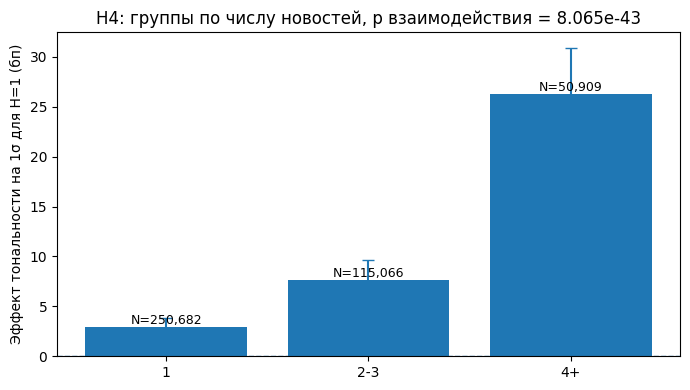

Сохранено: outputs_01/analysis_03-H4/fig_H4_news_volume_bins.png


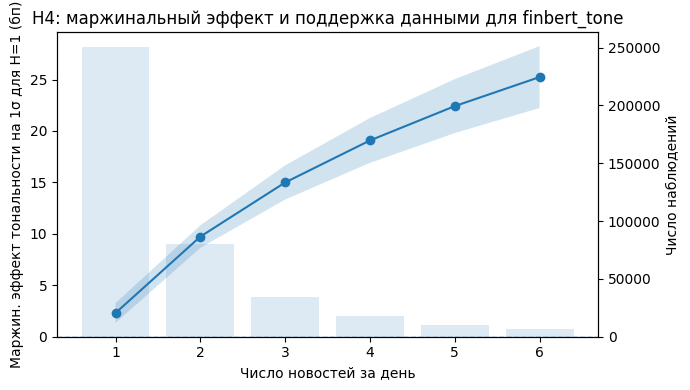

Сохранено: outputs_01/analysis_03-H4/fig_H4_marginal_effect_curve.png


In [9]:
fig_path = os.path.join(ANALYSIS_DIR, "fig_H4_news_volume_bins.png")
tmp = h4_bins.copy()
order = {"1": 0, "2-3": 1, "4+": 2}
tmp["ord"] = tmp["news_bin"].map(order)
tmp = tmp.sort_values("ord")

x = np.arange(len(tmp))
y = tmp["beta_1sd"].values * 10000
err = 1.96 * tmp["se_1sd"].values * 10000

plt.figure(figsize=(7, 4))
plt.bar(x, y)
plt.errorbar(x, y, yerr=err, fmt="none", capsize=4)
for xi, ni in zip(x, tmp["n_train"].values):
    plt.text(xi, y[xi], f"N={int(ni):,}", ha="center", va="bottom", fontsize=9)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, [NEWS_BIN_NAME_MAP.get(v, v) for v in tmp["news_bin"]])
p_two = float(h4_inter["p_two_sided"].iloc[0]) if len(h4_inter) else np.nan
plt.ylabel("Эффект тональности на 1σ для H=1 (бп)")
plt.title(f"H4: группы по числу новостей, p взаимодействия = {p_two:.4g}")
plt.tight_layout()
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print("Сохранено:", fig_path)

fig_path = os.path.join(ANALYSIS_DIR, "fig_H4_marginal_effect_curve.png")
tmp = h4_marginal.copy()

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(tmp["news_n"], tmp["beta_1sd_bps"], marker="o")
ax1.fill_between(tmp["news_n"], tmp["ci_lo_bps"], tmp["ci_hi_bps"], alpha=0.2)
ax1.axhline(0, linestyle="--", linewidth=1)
ax1.set_xlabel("Число новостей за день")
ax1.set_ylabel("Маржин. эффект тональности на 1σ для H=1 (бп)")

ax2 = ax1.twinx()
ax2.bar(tmp["news_n"], tmp["obs_count"], alpha=0.15)
ax2.set_ylabel("Число наблюдений")

ax1.set_title(f"H4: маржинальный эффект и поддержка данными для {pretty_model_name(MAIN_MODEL)}")
fig.tight_layout()
fig.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print("Сохранено:", fig_path)

In [10]:
from scipy.stats import t as student_t

H4_OOS_CACHE = os.path.join(ANALYSIS_DIR, "H4_test_sorts_news_bins.parquet")
H4_OOS_SIG = os.path.join(ANALYSIS_DIR, "H4_test_sorts_news_bins.signature.json")


def assign_news_bin(n):
    if n <= 1:
        return "1"
    if n <= 3:
        return "2-3"
    return "4+"


def run_h4_test_sorts_by_news_bin(df_in, q=TEST_SORT_Q):
    y_col = "y1_ex"
    x_col = f"{MAIN_MODEL}_score_mean"

    sample = select_sample(df_in, news_only=USE_NEWS_ONLY_PRIMARY)
    train, test = horizon_safe_split(sample, y_col, TEST_START)

    required = ["ticker", "date", y_col, x_col, "news_n"]
    tr = clean_required(train, required, [y_col, x_col, "news_n"])
    te = clean_required(test, required, [y_col, x_col, "news_n"])
    if tr.empty or te.empty:
        return pd.DataFrame()

    if APPLY_TRAIN_WINSOR:
        tr, te, _ = apply_train_winsor_pair(tr, te, y_col, p=WINSOR_P)

    _, mu, sd = standardize_on_train(tr[x_col], tr[x_col])
    if not (np.isfinite(sd) and sd > 0):
        return pd.DataFrame()
    te = te.copy()
    te["sent_z"] = (pd.to_numeric(te[x_col], errors="coerce") - mu) / sd
    te = te.dropna(subset=["sent_z"]).copy()
    te["news_bin"] = te["news_n"].astype(int).map(assign_news_bin)

    rows = []
    for bin_name in ["1", "2-3", "4+"]:
        sub = te[te["news_bin"] == bin_name].copy()
        if sub.empty:
            continue

        sub["bucket"] = (
            sub.groupby("date", sort=False)["sent_z"]
               .transform(lambda s: assign_quantile_by_date(s, q=q))
        )
        sub = sub.dropna(subset=["bucket"]).copy()
        if sub.empty:
            continue

        daily = (
            sub.groupby(["date", "bucket"], as_index=False)[y_col]
               .mean()
               .pivot(index="date", columns="bucket", values=y_col)
               .sort_index()
        )
        if "1" not in daily.columns or str(q) not in daily.columns:
            continue

        spread = daily[str(q)] - daily["1"]
        n = int(spread.notna().sum())
        mean_spread = float(spread.mean()) if n else np.nan
        se_spread = float(spread.std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan
        t_spread = mean_spread / se_spread if np.isfinite(se_spread) and se_spread > 0 else np.nan
        p_two = float(2 * student_t.sf(abs(t_spread), max(n - 1, 1))) if np.isfinite(t_spread) else np.nan

        rows.append({
            "news_bin": bin_name,
            "n_test_obs": int(len(sub)),
            "n_test_dates": n,
            "spread_q_last_minus_q1_bps": 10000 * mean_spread if np.isfinite(mean_spread) else np.nan,
            "se_spread_bps": 10000 * se_spread if np.isfinite(se_spread) else np.nan,
            "t_spread": t_spread,
            "p_two_sided": p_two,
        })

    return pd.DataFrame(rows)


h4_oos = load_cache(H4_OOS_CACHE, H4_OOS_SIG, MASTER_SIG) if USE_CACHE else None
if h4_oos is None:
    h4_oos = run_h4_test_sorts_by_news_bin(df, q=TEST_SORT_Q)
    save_cache(h4_oos, H4_OOS_CACHE, H4_OOS_SIG, MASTER_SIG)
    print("Сохранено:", H4_OOS_CACHE)
else:
    print("Загружено из кэша:", H4_OOS_CACHE)

display(h4_oos)

Сохранено: outputs_01/analysis_03-H4/H4_test_sorts_news_bins.parquet


,news_bin,n_test_obs,n_test_dates,spread_q_last_minus_q1_bps,se_spread_bps,t_spread,p_two_sided
0,1,69032,242,16.095355,3.293500,4.887006,0.000002
1,2-3,33553,242,10.736116,4.679914,2.294084,0.022647
2,4+,15064,242,7.327713,7.302124,1.003504,0.316624
